# **Resnet Training**

In [1]:
#imports
# For Data Processing
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# For ML Models
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.models import *
from tensorflow.keras.metrics import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.applications import *
from tensorflow.keras.utils import load_img
from tensorflow.keras.callbacks import EarlyStopping

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#miscellaneous
#from tqdm import tqdm
import os
import random
import numpy as np
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt


2026-03-11 14:35:53.452841: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 14:35:53.513560: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/ayeyushh451/miniconda3/envs/tensorflow-ml/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
2026-03-11 14:35:56.283403: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical 

In [2]:
batch_size = 8
img_height = 300
img_width = 300
data_dir = "Brain_Tumor_new/Training"
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)


Found 8582 files belonging to 4 classes.
Using 6866 files for training.


2026-03-11 14:36:04.762129: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Found 8582 files belonging to 4 classes.
Using 1716 files for validation.


In [3]:
for images, labels in val_ds.take(1):
    print(images.shape)
    print(labels.shape)


(8, 300, 300, 3)
(8, 4)


2026-03-11 14:36:08.400607: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
import tensorflow as tf

NUM_CLASSES = 4
IMAGE_SIZE_RESNET = 224

# Define augmentation layers once
resnet_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

# Training preprocessing
def preprocess_resnet_train(x, y):
    x = tf.image.resize(x, [IMAGE_SIZE_RESNET, IMAGE_SIZE_RESNET])
    x = resnet_augmentation(x)  # use the pre-defined layers
    x = tf.keras.applications.resnet.preprocess_input(x)
    return x, y

# Validation preprocessing
def preprocess_resnet_val(x, y):
    x = tf.image.resize(x, [IMAGE_SIZE_RESNET, IMAGE_SIZE_RESNET])
    x = tf.keras.applications.resnet.preprocess_input(x)
    return x, y


In [6]:
train_ds_resnet = train_ds.map(preprocess_resnet_train, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_resnet = val_ds.map(preprocess_resnet_val, num_parallel_calls=tf.data.AUTOTUNE)

train_ds_resnet = train_ds_resnet.prefetch(tf.data.AUTOTUNE)
val_ds_resnet = val_ds_resnet.prefetch(tf.data.AUTOTUNE)

In [7]:
for images, labels in train_ds_resnet.take(1):
    print(images[0].shape)  # first image in batch
    print(labels[0].shape)  # first label


(224, 224, 3)
(4,)


2026-03-11 14:36:27.810573: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
train_batches = tf.data.experimental.cardinality(train_ds_resnet).numpy()
print("Number of batches in train_ds:", train_batches)

num_train_samples = train_batches * batch_size
print("Estimated number of training samples:", num_train_samples)

Number of batches in train_ds: 859
Estimated number of training samples: 6872


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers

NUM_CLASSES = 4

# Load pretrained base model (ResNet50 here; adjust input_shape if needed)
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling=None
)

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Sequential model
model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.016)),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile
optimizer = optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,638,852 (93.99 MB)

 Trainable params: 1,051,140 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint
early_stop = EarlyStopping(
    monitor='val_loss',       # or 'val_accuracy' if you prefer
    patience=3,               # number of epochs with no improvement to wait
    restore_best_weights=True # restore model weights from the epoch with the best value
)

checkpoint = ModelCheckpoint(
    "resnet_before_unfreezing.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

optimizer = optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=10,
    batch_size=batch_size,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.6801 - loss: 10.5071
Epoch 1: val_loss improved from None to 4.50448, saving model to resnet_before_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 391s 452ms/step - accuracy: 0.7770 - loss: 7.9538 - val_accuracy: 0.8794 - val_loss: 4.5045
Epoch 2/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.8578 - loss: 3.8513
Epoch 2: val_loss improved from 4.50448 to 2.23728, saving model to resnet_before_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 356s 414ms/step - accuracy: 0.8638 - loss: 3.2572 - val_accuracy: 0.9073 - val_loss: 2.2373
Epoch 3/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.8746 - loss: 2.0601
Epoch 3: val_loss improved from 2.23728 to 1.39763, saving model to resnet_before_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 330s 384ms/step - accuracy: 0.8778 - loss: 1.8289 - val_accuracy: 0.9003 - val_loss: 1.3976
Epoch 4/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8715 - loss: 1.3401
Epoch 4: val_loss improved from 1.39763 to 0.99376, saving model to resnet_before_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 349s 406ms/step - accuracy: 0.8756 - loss: 1.2220 - val_accuracy: 0.8951 - val_loss: 0.9938
Epoch 5/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.8821 - loss: 0.9748
Epoch 5: val_loss improved from 0.99376 to 0.76233, saving model to resnet_before_unfreezing.h5


...

859/859 ━━━━━━━━━━━━━━━━━━━━ 340s 396ms/step - accuracy: 0.8842 - loss: 0.7379 - val_accuracy: 0.8718 - val_loss: 0.6942
Epoch 7/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8874 - loss: 0.6681
Epoch 7: val_loss improved from 0.69418 to 0.52235, saving model to resnet_before_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 376s 388ms/step - accuracy: 0.8918 - loss: 0.6323 - val_accuracy: 0.9231 - val_loss: 0.5224
Epoch 8/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8843 - loss: 0.5849
Epoch 8: val_loss improved from 0.52235 to 0.49727, saving model to resnet_before_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 318s 371ms/step - accuracy: 0.8883 - loss: 0.5641 - val_accuracy: 0.9079 - val_loss: 0.4973
Epoch 9/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.8878 - loss: 0.5315
Epoch 9: val_loss improved from 0.49727 to 0.47105, saving model to resnet_before_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 318s 370ms/step - accuracy: 0.8922 - loss: 0.5142 - val_accuracy: 0.9062 - val_loss: 0.4711
Epoch 10/10
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.8959 - loss: 0.4918
Epoch 10: val_loss improved from 0.47105 to 0.46686, saving model to resnet_before_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 318s 370ms/step - accuracy: 0.9001 - loss: 0.4814 - val_accuracy: 0.8963 - val_loss: 0.4669


In [8]:
from tensorflow.keras import optimizers
from tensorflow.keras.models import load_model
model = load_model("resnet_before_unfreezing.h5")
base_model=model.layers[0]
optimizer = optimizers.Adam(learning_rate=1e-4)
for layer in base_model.layers:
    if "conv4_block" in layer.name or "conv5_block" in layer.name:
        layer.trainable = True

# Ensure Dense layers are trainable
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        layer.trainable = True

# Recompile with smaller learning rate
optimizer = optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint
early_stop = EarlyStopping(
    monitor='val_loss',       # or 'val_accuracy' if you prefer
    patience=3,               # number of epochs with no improvement to wait
    restore_best_weights=True # restore model weights from the epoch with the best value
)

checkpoint = ModelCheckpoint(
    "resnet_after_unfreezing.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)
history = model.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=20,
    batch_size=batch_size,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step - accuracy: 0.9098 - loss: 0.4083
Epoch 1: val_loss improved from None to 0.28018, saving model to resnet_after_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 846s 985ms/step - accuracy: 0.9219 - loss: 0.3622 - val_accuracy: 0.9429 - val_loss: 0.2802
Epoch 2/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 850ms/step - accuracy: 0.9601 - loss: 0.2212
Epoch 2: val_loss improved from 0.28018 to 0.14713, saving model to resnet_after_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 807s 939ms/step - accuracy: 0.9605 - loss: 0.2018 - val_accuracy: 0.9662 - val_loss: 0.1471
Epoch 3/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.9740 - loss: 0.1458
Epoch 3: val_loss improved from 0.14713 to 0.09711, saving model to resnet_after_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 855s 996ms/step - accuracy: 0.9731 - loss: 0.1400 - val_accuracy: 0.9779 - val_loss: 0.0971
Epoch 4/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.9766 - loss: 0.1216
Epoch 4: val_loss did not improve from 0.09711
859/859 ━━━━━━━━━━━━━━━━━━━━ 778s 906ms/step - accuracy: 0.9754 - loss: 0.1235 - val_accuracy: 0.9767 - val_loss: 0.1003
Epoch 5/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.9850 - loss: 0.0861
Epoch 5: val_loss improved from 0.09711 to 0.07629, saving model to resnet_after_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 761s 886ms/step - accuracy: 0.9841 - loss: 0.0880 - val_accuracy: 0.9866 - val_loss: 0.0763
Epoch 6/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.9834 - loss: 0.0914
Epoch 6: val_loss improved from 0.07629 to 0.05759, saving model to resnet_after_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 754s 878ms/step - accuracy: 0.9837 - loss: 0.0876 - val_accuracy: 0.9930 - val_loss: 0.0576
Epoch 7/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.9816 - loss: 0.0855
Epoch 7: val_loss did not improve from 0.05759
859/859 ━━━━━━━━━━━━━━━━━━━━ 746s 868ms/step - accuracy: 0.9822 - loss: 0.0839 - val_accuracy: 0.9848 - val_loss: 0.0948
Epoch 8/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.9865 - loss: 0.0740
Epoch 8: val_loss did not improve from 0.05759
859/859 ━━━━━━━━━━━━━━━━━━━━ 736s 857ms/step - accuracy: 0.9875 - loss: 0.0678 - val_accuracy: 0.9854 - val_loss: 0.0732
Epoch 9/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.9868 - loss: 0.0731
Epoch 9: val_loss improved from 0.05759 to 0.04888, saving model to resnet_after_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 738s 859ms/step - accuracy: 0.9859 - loss: 0.0741 - val_accuracy: 0.9936 - val_loss: 0.0489
Epoch 10/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.9879 - loss: 0.0583
Epoch 10: val_loss improved from 0.04888 to 0.03727, saving model to resnet_after_unfreezing.h5


859/859 ━━━━━━━━━━━━━━━━━━━━ 783s 911ms/step - accuracy: 0.9900 - loss: 0.0526 - val_accuracy: 0.9942 - val_loss: 0.0373
Epoch 11/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 0.9863 - loss: 0.0646
Epoch 11: val_loss did not improve from 0.03727
859/859 ━━━━━━━━━━━━━━━━━━━━ 834s 971ms/step - accuracy: 0.9897 - loss: 0.0574 - val_accuracy: 0.9913 - val_loss: 0.0420
Epoch 12/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.9880 - loss: 0.0784
Epoch 12: val_loss did not improve from 0.03727
859/859 ━━━━━━━━━━━━━━━━━━━━ 815s 948ms/step - accuracy: 0.9907 - loss: 0.0602 - val_accuracy: 0.9860 - val_loss: 0.0906
Epoch 13/20
859/859 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.9895 - loss: 0.0652
Epoch 13: val_loss did not improve from 0.03727
859/859 ━━━━━━━━━━━━━━━━━━━━ 780s 907ms/step - accuracy: 0.9908 - loss: 0.0519 - val_accuracy: 0.9924 - val_loss: 0.0444


In [9]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load model
resnet_test = load_model("resnet_after_unfreezing.h5")

# Test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    "Brain_Tumor_new/Testing",
    labels="inferred",
    label_mode="categorical",  # one-hot labels
    batch_size=8,
    image_size=(224, 224),
    shuffle=False
)

# Apply preprocessing
test_ds_resnet = test_ds.map(lambda x, y: (preprocess_input(x), y),
                             num_parallel_calls=tf.data.AUTOTUNE)
test_ds_resnet = test_ds_resnet.prefetch(tf.data.AUTOTUNE)

# Evaluate
test_loss, test_acc = resnet_test.evaluate(test_ds_resnet)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Found 1705 files belonging to 4 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 103s 472ms/step - accuracy: 0.9413 - loss: 0.4857
Test loss: 0.4857
Test accuracy: 0.9413


214/214 ━━━━━━━━━━━━━━━━━━━━ 77s 355ms/step


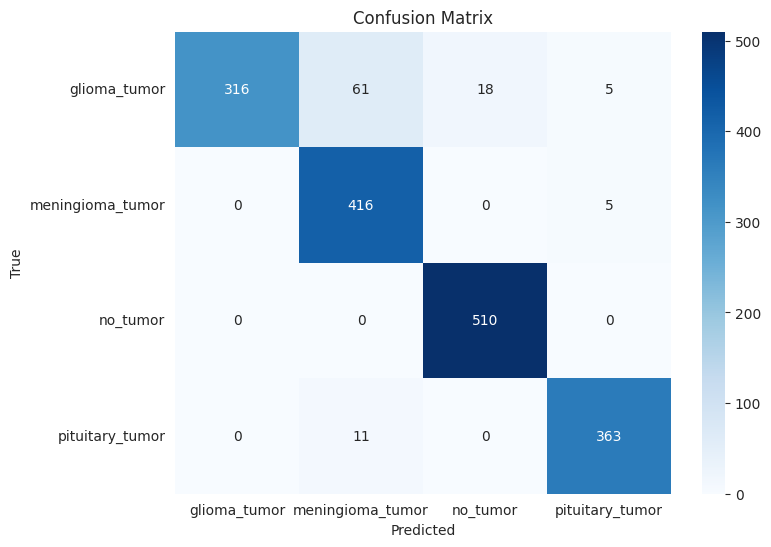

                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.79      0.88       400
meningioma_tumor       0.85      0.99      0.92       421
        no_tumor       0.97      1.00      0.98       510
 pituitary_tumor       0.97      0.97      0.97       374

        accuracy                           0.94      1705
       macro avg       0.95      0.94      0.94      1705
    weighted avg       0.95      0.94      0.94      1705



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get true labels and predictions
y_true = np.concatenate([y for x, y in test_ds_resnet], axis=0)   # one-hot labels
y_true = np.argmax(y_true, axis=1)  # convert one-hot to class indices

y_pred_probs = resnet_test.predict(test_ds_resnet)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Get class names from dataset
class_names = test_ds.class_names   # same order as dataset

# 4. Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# 5. Print detailed report
print(classification_report(y_true, y_pred, target_names=class_names))


In [11]:
import pandas as pd

# CSV with per-sample true vs predicted labels
df_preds = pd.DataFrame({
    "True_Label": [class_names[i] for i in y_true],
    "Predicted_Label": [class_names[i] for i in y_pred]
})
df_preds.to_csv("resnet_predictions.csv", index=False)

# Confusion matrix as a CSV (rows=True, cols=Predicted)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
df_cm.index.name = "True_Label"
df_cm.columns.name = "Predicted_Label"
df_cm.to_csv("resnet_confusion_matrix.csv")

print("Saved: resnet_predictions.csv, resnet_confusion_matrix.csv")

Saved: resnet_predictions.csv, resnet_confusion_matrix.csv
